In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
%matplotlib inline

In [118]:
X, y = make_blobs(n_samples=1000, centers=3, n_features=2, random_state=23)

In [119]:
X.shape

(1000, 2)

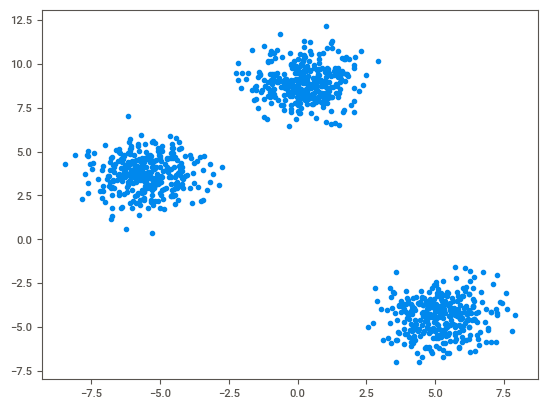

In [120]:
plt.scatter(X[:,0], X[:,1])

In [121]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [122]:
from sklearn.cluster import KMeans

In [123]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)

In [124]:
wcss

[34827.576825520235,
 7935.437286145425,
 1319.2730531585605,
 1170.8919159814807,
 1032.32388105457,
 904.8630822732223,
 849.4150173356991,
 789.5649463139617,
 620.4194050785012,
 539.5140283445327]

Text(0, 0.5, 'WCSS')

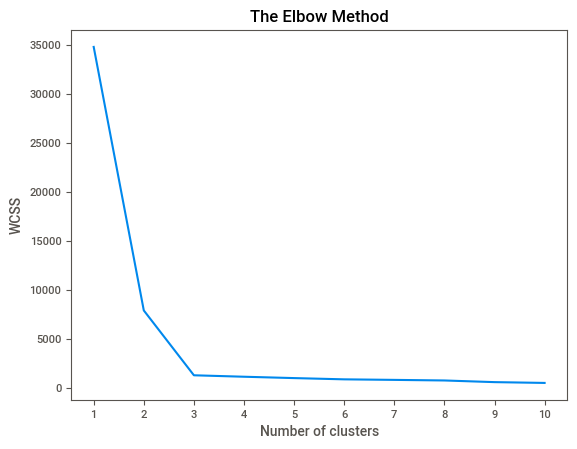

In [125]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

In [126]:
kmeans = KMeans(n_clusters=3, init='k-means++')
y_labels = kmeans.fit_predict(X_train)

In [127]:
y_test_labels = kmeans.predict(X_test)

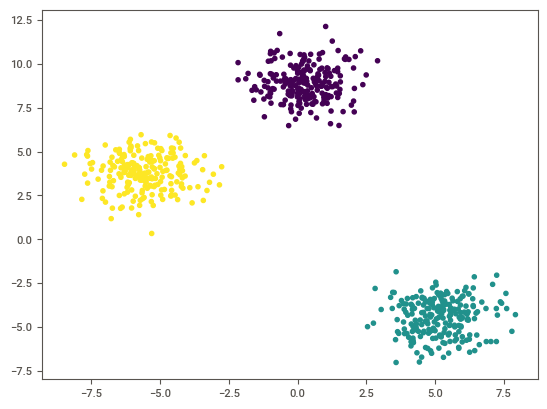

In [128]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_labels)

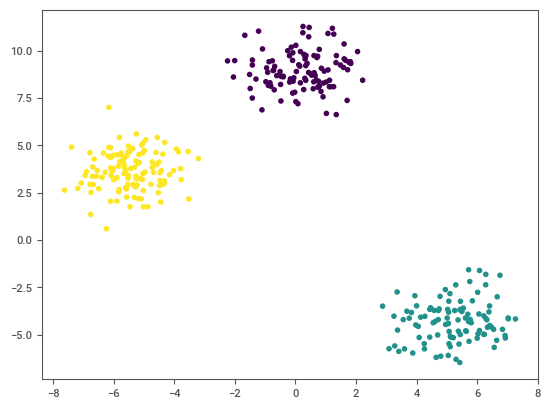

In [129]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_test_labels)

In [130]:
!pip install kneed

**Shortest way to find clusters**

In [131]:
from kneed import KneeLocator

In [132]:
kl =KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
kl.elbow

np.int64(3)

In [133]:
from sklearn.metrics import silhouette_score

In [134]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    score = silhouette_score(X_train, kmeans.labels_)
    silhouette_coefficients.append(score)

In [135]:
silhouette_coefficients

[np.float64(0.7281443868598331),
 np.float64(0.8071181203797672),
 np.float64(0.6357733426488265),
 np.float64(0.6446292946026217),
 np.float64(0.48675048732523835),
 np.float64(0.3347588400720747),
 np.float64(0.3356383100041827),
 np.float64(0.33864321719188945),
 np.float64(0.3196320793333945)]

Text(0, 0.5, 'Silhouette Coefficient')

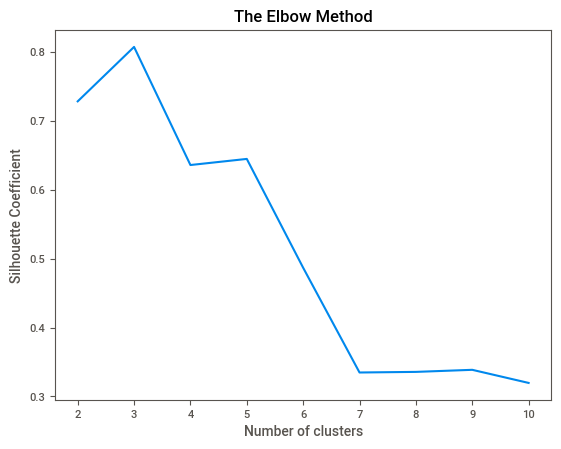

In [136]:
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Coefficient')